# NOTEBOOK 1 (Live 1) — Du ML au Deep Learning (ANN Dense)

### Objectifs :

* Comprendre la limite d’un modèle linéaire  

* Voir qu’un modèle ML non linéaire peut déjà bien marcher. 

* Comprendre "Pourquoi quand même du Deep Learning ?"  

* Découvrir l’API Keras/TensorFlow (Sequential, Dense, compile, fit). 

* Entraîner un ANN simple et comparer les frontières de décision. 


## 0) Imports, Setup & Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import tensorflow as tf


# Fix seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Versions:")
print(" - numpy:", np.__version__)
print(" - tensorflow:", tf.__version__)

Versions:
 - numpy: 1.26.4
 - tensorflow: 2.16.2


### Génération d’un dataset non linéaire (make_moons)
On crée un dataset 2D volontairement NON linéairement séparables.  
Intuition : une frontière "droite" ne suffira pas.


Shape X: (1200, 2)
Shape y: (1200,)
Classes: [0 1]


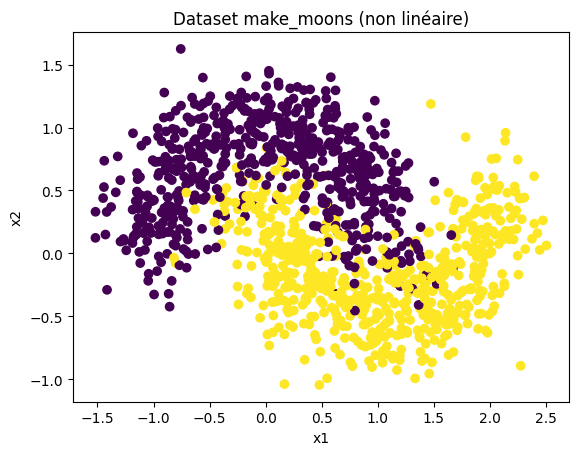

In [2]:
X, y = make_moons(n_samples=1200, noise=0.25, random_state=42)

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Classes:", np.unique(y))

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dataset make_moons (non linéaire)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

### Split Train/Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

### Fonction utilitaire : tracer une frontière de décision

In [4]:
def plot_decision_boundary_sklearn(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

## A. Modèles ML Classiques : Regression Logistique et SVM linéaire

### Baseline ML linéaire : Régression Logistique


=== Logistic Regression (linéaire) ===
Accuracy test: 0.8767
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       150
           1       0.90      0.85      0.87       150

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



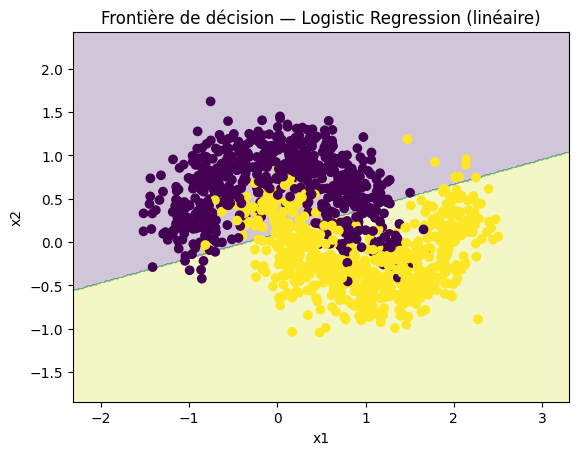

In [5]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("\n=== Logistic Regression (linéaire) ===")
print("Accuracy test:", round(acc_lr, 4))
print(classification_report(y_test, y_pred_lr))

plot_decision_boundary_sklearn(
    model=log_reg,
    X=X,
    y=y,
    title="Frontière de décision — Logistic Regression (linéaire)"
)

### Modèle ML non linéaire classique : SVM RBF


=== SVM RBF (non linéaire) ===
Accuracy test: 0.95
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       150
           1       0.96      0.94      0.95       150

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



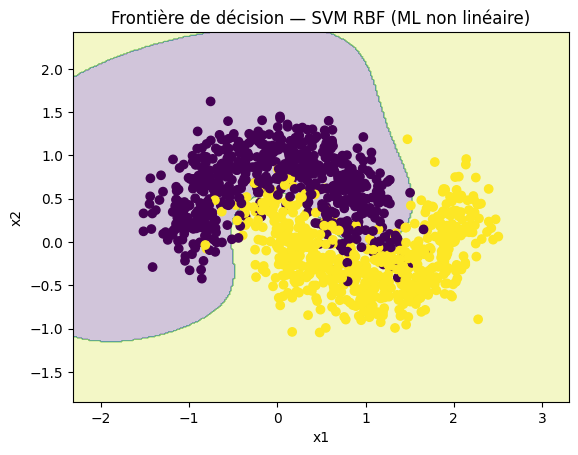

In [6]:
svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=3.0, gamma="scale"))
])

svm_rbf.fit(X_train, y_train)

y_pred_svm = svm_rbf.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("\n=== SVM RBF (non linéaire) ===")
print("Accuracy test:", round(acc_svm, 4))
print(classification_report(y_test, y_pred_svm))

plot_decision_boundary_sklearn(
    model=svm_rbf,
    X=X,
    y=y,
    title="Frontière de décision — SVM RBF (ML non linéaire)"
)

## Pourquoi ne pas s’arrêter à un modèle non linéaire ML ?

> ### Question clé :
> ### "Si un SVM RBF marche très bien, pourquoi faire du Deep Learning ?"

### Réponse

### 1) Sur données tabulaires simples, les modèles ML non linéaires sont souvent excellents.

### 2) Mais sur données non structurées (images, audio, texte), on veut :

- #### apprendre automatiquement les représentations (features) à partir des données brutes

- #### construire des architectures modulaires (Dense, CNN, RNN, etc.)

- #### faire de l’apprentissage end-to-end (data brute -> prédiction)

### 3) Le Deep Learning est donc moins "une solution magique", et plus :

- #### un cadre flexible et scalable pour les données complexes.

> ### IMPORTANT :  
> #### On ne dit pas "DL > ML" partout.  
> #### On dit : "DL est souvent pertinent quand les features sont complexes ou non structurées."  

## B. Introduction à Keras / TensorFlow : ANN Dense simple

### Keras (dans TensorFlow) suit presque toujours le même pattern :
- #### 1) Définir le modèle (architecture)
- #### 2) Compiler (loss, optimizer, metrics)
- #### 3) Entraîner (fit)

### Ici on crée un ANN (réseau fully-connected) minimal, avec Dense

In [ ]:
- -- Standardisation ---
# En deep learning, on standardise souvent les inputs pour aider l’optimisation.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Définition du modèle (Sequential + Dense)

#### Architecture :

- Dense(8, relu) : couche cachée (apprend des transformations non linéaires). 

- Dense(1, sigmoid) : sortie binaire (probabilité classe 1). 
  
> input_shape=(2,) car on a 2 features (x1, x2).

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation="relu", input_shape=(2,)),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

/Users/jika/Desktop/PRO/ALYRA - IA/ai-dev-teaching-hub/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-02 00:42:32.511073: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-02 00:42:32.511310: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-02 00:42:32.511342: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-02 00:42:32.511495: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-02 00:42:32.511538: I tensorflow/core/common_runtime/pluggable_device/plugg

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

### Compilation (optimizer, loss, metrics)

- optimizer : comment on met à jour les poids (ex: Adam)

- loss : ce qu’on cherche à minimiser (binary_crossentropy pour binaire)

- metrics : ce qu’on affiche (accuracy)

In [9]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Entraînement (fit)

- epochs : nb de passages sur le dataset

- validation_split : on garde une partie du train pour suivre la généralisation


In [10]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print("\nTraining terminé.")

2026-03-02 00:44:11.946079: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



Training terminé.


### Évaluation sur le test

In [11]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print("\n=== ANN Dense (Keras) ===")
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))

# Prédictions (probas -> classes)
y_proba = model.predict(X_test_scaled, verbose=0).ravel()
y_pred_nn = (y_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred_nn))


=== ANN Dense (Keras) ===
Test loss: 0.3126
Test accuracy: 0.8767
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       150
           1       0.89      0.86      0.87       150

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



### Visualisation des courbes (loss & accuracy)

- Objectif : Il faut s'habituer à lire un training.

- On approfondira callbacks / TensorBoard dans les autres notebooks. 

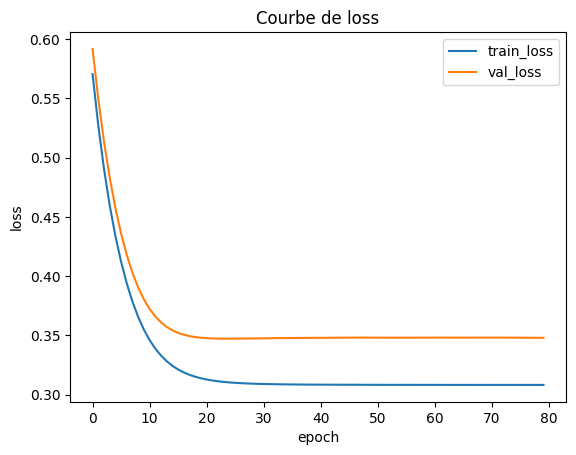

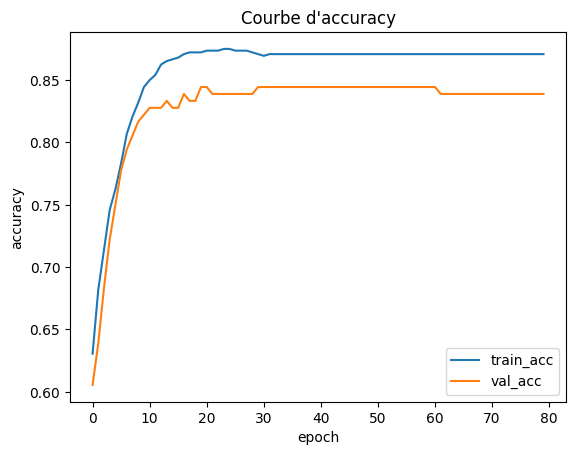

In [12]:
plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Courbe de loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Courbe d'accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()


### Frontière de décision (réseau)

> #### Attention :
> - Notre réseau attend des inputs standardisés.
>
> - Dans la fonction de tracé, on standardise la grille avec le scaler déjà fit.



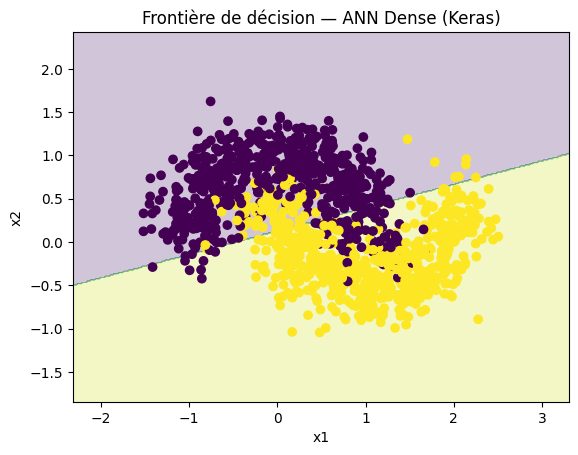

In [14]:
def plot_decision_boundary_keras(model, scaler, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    grid_scaled = scaler.transform(grid)
    proba = model.predict(grid_scaled, verbose=0).ravel()
    Z = (proba >= 0.5).astype(int).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


plot_decision_boundary_keras(
    model=model,
    scaler=scaler,
    X=X,
    y=y,
    title="Frontière de décision — ANN Dense (Keras)"
)

## Conclusion / Messages clés

### Récapitulatif des messages clés à retenir :

-  Un modèle linéaire (LogReg) est limité par sa forme : frontière "droite".
-  Un modèle ML non linéaire (SVM RBF) peut déjà résoudre un problème courbe.
-  Le Deep Learning n’est pas "toujours meilleur", mais il est souvent pertinent quand :

    * les données sont non structurées (images, texte, audio)

    * on veut apprendre automatiquement des représentations

    * on veut construire des architectures modulaires (Dense/CNN/RNN/...)

-  Keras : pattern standard à retenir :

   1) model = Sequential([...])

   2) model.compile(optimizer, loss, metrics)

   3) history = model.fit(...)


### Mini questions (auxqelles savoir répondre pour le jury final):

1) Pourquoi ReLU est utile dans une couche cachée ?

2) Quelle différence entre loss et accuracy ?

3) Que signifie "validation_split" ?

4) Est-ce que le modèle overfit ? Comment le voir sur les courbes ?